# 🏷️ PP9 — Named Entity Recognition (NER)
### Gudsky Research Foundation · Research Intake 2026 · Day 15
**Module:** Natural Language Processing  
**References:** ML Journey (Peter Song, 2025) · GeeksforGeeks NER · ds4j-notebooks (littlecolumns)  

---

## 📋 What You Will Learn in This Notebook

| Section | Topic | Difficulty |
|---------|-------|------------|
| 1 | What is NER? Concepts & Entity Types | 🟢 Beginner |
| 2 | IOB / BIOES Labelling Schemes | 🟢 Beginner |
| 3 | NER with spaCy — Sentences & Paragraphs | 🟢 Beginner |
| 4 | Visualisation with displacy | 🟢 Beginner |
| 5 | NER on Real News Articles | 🟡 Intermediate |
| 6 | NER with NLTK | 🟡 Intermediate |
| 7 | NER with HuggingFace Transformers (BERT) | 🔴 Advanced |
| 8 | Evaluation: Span-Level F1 | 🔴 Advanced |
| 9 | Error Analysis & Model Limitations | 🟡 Intermediate |
| 10 | Assignment Practice Exercises | ⭐ Graded |

---

> **Note on coding libraries:**  
> NER can be implemented using several Python libraries — **spaCy**, **NLTK**, and **HuggingFace Transformers** are the most popular. This notebook covers all three so you understand their differences. Deeper coding practice for each library will be covered in dedicated coding sessions.

---
## 🔵 Section 1: What is Named Entity Recognition?

**Named Entity Recognition (NER)** is the NLP task of identifying and classifying *named real-world entities* in text into predefined categories.

### Why does NER matter?
NER transforms **unstructured text → structured knowledge**. Instead of storing raw sentences, we store facts:

```
Raw text:   "Apple acquired Beats for $3 billion in 2014."
Structured: { ORG: 'Apple', ORG: 'Beats', MONEY: '$3 billion', DATE: '2014' }
```

This powers: **search engines**, **knowledge graphs**, **financial dashboards**, **clinical records**, **legal document review**, and much more.

---

### 📊 Standard Entity Types

| Entity Type | Code | Examples | Real-World Use |
|-------------|------|----------|----------------|
| Person | `PER` / `PERSON` | Barack Obama, Elon Musk | Biographical databases, authorship |
| Organisation | `ORG` | Google, WHO, MIT | Corporate intelligence |
| Geopolitical Entity | `GPE` | India, Paris, New York | Event mapping, travel |
| Location | `LOC` | Amazon River, Mount Everest | Geography, logistics |
| Date | `DATE` | 2 March 2024, Q3 2023 | Timeline extraction |
| Time | `TIME` | 3:30 PM, midnight | Scheduling, log parsing |
| Money | `MONEY` | $3 billion, ₹10 crore | Financial news analysis |
| Product | `PRODUCT` | iPhone 15, ChatGPT | Competitive intelligence |
| Event | `EVENT` | World Cup 2022, COVID-19 | Event tracking |
| Nationality/Language | `NORP` | Indian, French, Buddhist | Demographic analysis |

---

### 🌍 Real-World Example: Reuters News Wire
Reuters processes **over 1 million articles per day** through their NER pipeline. Every article is automatically tagged for PER, ORG, GPE, and MONEY entities. These extracted entities power the **Thomson Reuters Eikon financial terminal** — allowing traders to filter news by company or country *without reading the full article*.

### 🌍 Real-World Example: Context Changes Entity Meaning
The same word can mean completely different things:

```
"Amazon is expanding rapidly"     → Amazon = ORG  (technology company)
"The Amazon is the largest river" → Amazon = LOC  (river in South America)

"Jordan won the MVP award"        → Jordan = PER  (basketball player)
"Jordan is a country in the Middle East" → Jordan = GPE (country)
```
This is the *disambiguation challenge* NER models must solve using **surrounding context**.

---
## 🔵 Section 2: IOB & BIOES Labelling Schemes

Because entities span **multiple words** (e.g., "New York City" is one GPE entity), we cannot label each word independently. We use encoding schemes that capture both entity type AND position within the span.

### IOB2 Encoding (Most Common)

| Tag | Meaning | Example |
|-----|---------|----------|
| `B-TYPE` | **B**eginning of entity | `B-GPE` → start of a geopolitical entity |
| `I-TYPE` | **I**nside (continuation) of entity | `I-GPE` → continuation of GPE |
| `O` | **O**utside any entity | Not part of any named entity |

```
Sentence:  New    York   City   is    home   to    the   United  Nations
IOB Tags:  B-GPE  I-GPE  I-GPE   O     O      O     O    B-ORG   I-ORG
```

### BIOES Encoding (Higher Accuracy)
Adds two more tags for better boundary detection:

| Tag | Meaning |
|-----|---------|
| `S-TYPE` | **S**ingle-token entity (entire entity is one word) |
| `E-TYPE` | **E**nd of a multi-token entity span |

```
Sentence:  Barack  Obama  visited  Paris  and  United  Nations  headquarters
BIOES:     B-PER   E-PER     O     S-GPE   O   B-ORG   I-ORG       O
```

> **Key Rule:** An `I-TYPE` tag must ALWAYS follow a `B-TYPE` tag of the **same type**. You can never have `B-PER → I-ORG`. This constraint is enforced by the CRF layer in neural NER models.

---
## 🔵 Section 3: NER with spaCy

**spaCy** is an industrial-strength NLP library for Python by Explosion AI. It is the most widely used NER library in production because it is:
- ⚡ Very fast (processes 10,000–50,000 words/second on CPU)
- 🎯 Accurate (90+ F1 with transformer-based models)
- 🔧 Easy to use with a clean Python API

### spaCy NER Models Available

| Model | Size | Use Case |
|-------|------|----------|
| `en_core_web_sm` | 12 MB | Fast prototyping, teaching |
| `en_core_web_md` | 40 MB | General use with word vectors |
| `en_core_web_lg` | 560 MB | High accuracy production use |
| `en_core_web_trf` | 500 MB | Highest accuracy (RoBERTa-based) |

### Installation
```bash
pip install spacy
python -m spacy download en_core_web_sm
```

In [1]:
# ─── Install required libraries (run once) ───────────────────────────────────
# Uncomment the lines below if running for the first time:
# !pip install spacy
# !python -m spacy download en_core_web_sm
# !pip install nltk
# !pip install transformers
# !pip install seqeval

# ─── Core Imports ─────────────────────────────────────────────────────────────
import spacy
import pandas as pd
import requests
from bs4 import BeautifulSoup
from spacy import displacy
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ─── Load spaCy English Model ─────────────────────────────────────────────────
nlp = spacy.load("en_core_web_sm")

# Display settings
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_colwidth", 80)

print("✅ spaCy loaded successfully!")
print(f"   Model: en_core_web_sm")
print(f"   Pipeline components: {nlp.pipe_names}")

✅ spaCy loaded successfully!
   Model: en_core_web_sm
   Pipeline components: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


### 3.1 — NER on a Single Sentence
Let's start simple. We process a sentence through spaCy and examine the entities it finds.

Each entity (`ent`) has four key attributes:
- `ent.text` — the actual text of the entity
- `ent.label_` — the entity type (ORG, GPE, MONEY, etc.)
- `ent.start_char` — character index where the entity starts
- `ent.end_char` — character index where the entity ends

In [2]:
# ─── Basic NER on a single sentence ─────────────────────────────────────────
sentence = "Apple is looking at buying U.K. startup for $1 billion"
doc = nlp(sentence)

print(f"Sentence: '{sentence}'")
print("-" * 60)
print(f"{'Entity Text':<20} {'Type':<12} {'Start':>6} {'End':>6} {'Explanation'}")
print("-" * 60)

for ent in doc.ents:
    explanation = spacy.explain(ent.label_) or "No explanation available"
    print(f"{ent.text:<20} {ent.label_:<12} {ent.start_char:>6} {ent.end_char:>6}  {explanation}")

print("-" * 60)
print(f"\nTotal entities found: {len(doc.ents)}")

Sentence: 'Apple is looking at buying U.K. startup for $1 billion'
------------------------------------------------------------
Entity Text          Type          Start    End Explanation
------------------------------------------------------------
Apple                ORG               0      5  Companies, agencies, institutions, etc.
U.K.                 GPE              27     31  Countries, cities, states
$1 billion           MONEY            44     54  Monetary values, including unit
------------------------------------------------------------

Total entities found: 3


In [3]:
# ─── Demonstrating Context-Based Disambiguation ──────────────────────────────
# The same word "Amazon" means different things in different sentences

sentences = [
    "Amazon is expanding its cloud computing division rapidly.",
    "The Amazon is the largest river system in the world.",
    "Apple released the new iPhone at their Cupertino headquarters.",
    "Jordan won the MVP award at the basketball championship.",
    "Jordan is a country located in the Middle East."
]

print("=" * 70)
print("CONTEXT-BASED DISAMBIGUATION DEMO")
print("=" * 70)

for sent in sentences:
    doc = nlp(sent)
    print(f"\n📝 '{sent}'")
    if doc.ents:
        for ent in doc.ents:
            print(f"   → [{ent.text}] classified as: {ent.label_} ({spacy.explain(ent.label_)})")
    else:
        print("   → No entities found")

CONTEXT-BASED DISAMBIGUATION DEMO

📝 'Amazon is expanding its cloud computing division rapidly.'
   → [Amazon] classified as: ORG (Companies, agencies, institutions, etc.)

📝 'The Amazon is the largest river system in the world.'
   → [Amazon] classified as: ORG (Companies, agencies, institutions, etc.)

📝 'Apple released the new iPhone at their Cupertino headquarters.'
   → [Apple] classified as: ORG (Companies, agencies, institutions, etc.)
   → [Cupertino] classified as: GPE (Countries, cities, states)

📝 'Jordan won the MVP award at the basketball championship.'
   → [Jordan] classified as: PERSON (People, including fictional)
   → [MVP] classified as: ORG (Companies, agencies, institutions, etc.)

📝 'Jordan is a country located in the Middle East.'
   → [Jordan] classified as: GPE (Countries, cities, states)
   → [the Middle East] classified as: LOC (Non-GPE locations, mountain ranges, bodies of water)


### 3.2 — Extracting Entities into a DataFrame

For analysis, it's much easier to work with entities in a structured **pandas DataFrame**. We extract the text, label, and lemma (base form) of each entity.

In [4]:
# ─── Process a richer paragraph and build a DataFrame ────────────────────────
paragraph = """
Microsoft was founded by Bill Gates and Paul Allen in Albuquerque, New Mexico in 1975.
The company later moved its headquarters to Redmond, Washington.
In 2023, Microsoft announced a $10 billion investment in OpenAI,
the San Francisco-based company behind ChatGPT.
Satya Nadella, who became CEO in February 2014, has led Microsoft's transformation
into a cloud-first company. The company's Azure platform now competes with
Amazon Web Services and Google Cloud for dominance in the cloud market.
"""

doc = nlp(paragraph)

# Build entities list with extra metadata
entities = [
    {
        'text': ent.text.strip(),
        'type': ent.label_,
        'description': spacy.explain(ent.label_),
        'lemma': ent.lemma_,
        'start_char': ent.start_char,
        'end_char': ent.end_char
    }
    for ent in doc.ents
]

df = pd.DataFrame(entities)
print(f"Found {len(df)} entities in the paragraph:\n")
print(df.to_string(index=False))

Found 18 entities in the paragraph:

               text    type                             description               lemma  start_char  end_char
          Microsoft     ORG Companies, agencies, institutions, etc.           Microsoft           1        10
         Bill Gates  PERSON             People, including fictional          Bill Gates          26        36
         Paul Allen  PERSON             People, including fictional          Paul Allen          41        51
        Albuquerque     GPE               Countries, cities, states         Albuquerque          55        66
         New Mexico     GPE               Countries, cities, states          New Mexico          68        78
               1975    DATE   Absolute or relative dates or periods                1975          82        86
            Redmond     GPE               Countries, cities, states             Redmond         133       140
         Washington     GPE               Countries, cities, states          Washin

In [5]:
# ─── Analyse entity type distribution ────────────────────────────────────────
print("Entity Type Distribution:")
print("-" * 35)
type_counts = df['type'].value_counts()
for entity_type, count in type_counts.items():
    bar = '█' * count
    print(f"  {entity_type:<10} {bar:<20} {count}")

print("\nAll ORG entities found:")
print(df[df['type'] == 'ORG'][['text', 'lemma']].to_string(index=False))

print("\nAll PERSON entities found:")
print(df[df['type'] == 'PERSON'][['text', 'lemma']].to_string(index=False))

Entity Type Distribution:
-----------------------------------
  GPE        ██████               6
  ORG        ████                 4
  PERSON     ███                  3
  DATE       ███                  3
  MONEY      █                    1
  ORDINAL    █                    1

All ORG entities found:
               text               lemma
          Microsoft           Microsoft
          Microsoft           Microsoft
          Microsoft           Microsoft
Amazon Web Services Amazon Web Services

All PERSON entities found:
         text         lemma
   Bill Gates    Bill Gates
   Paul Allen    Paul Allen
Satya Nadella Satya Nadella


---
## 🔵 Section 4: Visualisation with displacy

spaCy's built-in `displacy` renderer creates beautiful HTML visualisations of NER results, highlighting each entity span with its label in a colour-coded format.

This is extremely useful for:
- **Quickly checking** what a model identified
- **Spotting errors** (wrong boundaries, wrong type)
- **Presenting results** to non-technical stakeholders

In [6]:
# ─── Visualise NER with displacy ─────────────────────────────────────────────
sample = "Elon Musk founded Tesla in Palo Alto, California in 2003. " \
         "SpaceX, his other company, launched its Starship rocket in March 2024. " \
         "The project cost over $2 billion."

doc_viz = nlp(sample)

# Custom colours for different entity types
colors = {
    "PERSON": "#ffadad",
    "ORG": "#a0c4ff",
    "GPE": "#caffbf",
    "DATE": "#fdffb6",
    "MONEY": "#ffd6a5",
    "PRODUCT": "#d0f4de"
}

options = {"ents": list(colors.keys()), "colors": colors}

# In Jupyter Notebook, this renders as HTML inline
displacy.render(doc_viz, style="ent", options=options)

In [8]:
# ─── Save displacy output as HTML file ───────────────────────────────────────
html = displacy.render(doc_viz, style="ent", options=options, page=True, jupyter=False)
with open("ner_visualisation.html", "w", encoding="utf-8") as f:
    f.write(html)
print("✅ Saved visualisation to 'ner_visualisation.html'")
print("   Open this file in any web browser to view the highlighted entities.")

✅ Saved visualisation to 'ner_visualisation.html'
   Open this file in any web browser to view the highlighted entities.


---
## 🔵 Section 5: NER on Real News Articles

Now let's work with a **real-world news article** — exactly the kind of text you would process in journalism, financial intelligence, or media monitoring.

This article is from the Washington Post about a fraud case. Let's use NER to automatically extract who, what, where, and when from the article.

### 🌍 Real-World Use Case: Automated News Intelligence
Companies like **Bloomberg**, **Reuters**, and **Associated Press** run NER on every published article. The extracted entities feed into:
- Market-moving event alerts (company names + money amounts)
- Geographic conflict monitoring (GPE entities)
- Executive tracking (PERSON entities near ORG entities)

In [9]:
# ─── Real News Article NER ────────────────────────────────────────────────────
article_text = """
The owner of a Virginia company that provides the U.S. Navy with ballistic vests,
protective helmets and riot gear is facing a federal wire fraud charge, accused of
misleading authorities about where the products were made.

Prosecutors said Arthur Morgan, the 67-year-old chief executive of Surveillance
Equipment Group Inc. and its division SEG Armor, falsely claimed the equipment was
made in Hong Kong and the United States when it in fact was made in mainland China.

According to federal court records, Morgan's company was an authorized seller of
law enforcement and security supplies to federal agencies. Such sales must comply
with the Trade Agreements Act, which requires products to be made or substantially
transformed in a designated country.

The United States includes Hong Kong, a special administrative region of China, on
its list of countries designated to make equipment under the act but excludes the
mainland. Surveillance Equipment Group became an authorized equipment provider in
2003 and has fulfilled multiple federal orders over the past 16 years.

In 2014, prosecutors said, the company's price list stated that concealable body
armor and helmets were made in Hong Kong. An Army special agent then checked pictures
Morgan's firm had filed with the GSA and detected that a photo of a helmet for sale
had been altered. When the agent did a reverse image search, he found the unaltered
photo on Alibaba.com, a Chinese e-commerce site.

Between 2015 and July of this year, prosecutors said, five federal agencies placed
nine orders for ballistic vests, helmets or riot gear from Surveillance Equipment
Group, totaling about $640,000.

On Thursday, a magistrate at U.S. District Court in Greenbelt, Md., ordered that
Morgan be released to home confinement after he paid a $75,000 bond.

If convicted, prosecutors said, Morgan could face a maximum sentence of 20 years
in federal prison.
"""

doc_article = nlp(article_text)
print(f"Article processed. Found {len(doc_article.ents)} entities.")
print(f"Total tokens: {len(doc_article)}")

Article processed. Found 36 entities.
Total tokens: 374


In [10]:
# ─── Build and analyse the entities DataFrame ─────────────────────────────────
entities_article = [(ent.text.strip(), ent.label_, ent.lemma_) for ent in doc_article.ents]
df_article = pd.DataFrame(entities_article, columns=['text', 'type', 'lemma'])

print("ALL ENTITIES FOUND IN ARTICLE:")
print("=" * 55)
print(df_article.to_string(index=False))

ALL ENTITIES FOUND IN ARTICLE:
                               text     type                               lemma
                           Virginia      GPE                            Virginia
                      the U.S. Navy      ORG                       the U.S. Navy
                      Arthur Morgan   PERSON                       Arthur Morgan
                        67-year-old     DATE                         67-year-old
Surveillance \nEquipment Group Inc.      ORG Surveillance \nEquipment Group Inc.
                          SEG Armor   PERSON                           SEG Armor
                          Hong Kong      GPE                           Hong Kong
                  the United States      GPE                   the United States
                              China      GPE                               China
                             Morgan      ORG                              Morgan
           the Trade Agreements Act      ORG            the Trade Agreements A

In [11]:
# ─── Targeted Entity Analysis ─────────────────────────────────────────────────
print("📍 GEOPOLITICAL ENTITIES (Where is the story set?):")
print(df_article[df_article.type == 'GPE'].lemma.value_counts().to_string())

print("\n👤 PERSONS MENTIONED:")
print(df_article[df_article.type == 'PERSON'].lemma.value_counts().to_string())

print("\n🏢 ORGANISATIONS MENTIONED:")
print(df_article[df_article.type == 'ORG'].lemma.value_counts().to_string())

print("\n💰 MONEY AMOUNTS:")
print(df_article[df_article.type == 'MONEY'][['text']].to_string(index=False))

print("\n📅 DATES:")
print(df_article[df_article.type == 'DATE'][['text']].to_string(index=False))

📍 GEOPOLITICAL ENTITIES (Where is the story set?):
lemma
Hong Kong            3
the United States    2
China                2
Virginia             1
Greenbelt            1
Md.                  1

👤 PERSONS MENTIONED:
lemma
Arthur Morgan    1
SEG Armor        1
Morgan           1

🏢 ORGANISATIONS MENTIONED:
lemma
Morgan                                 2
the U.S. Navy                          1
Surveillance \nEquipment Group Inc.    1
the Trade Agreements Act               1
Surveillance Equipment Group           1
Army                                   1
GSA                                    1
Alibaba.com                            1
Surveillance Equipment \nGroup         1
U.S. District Court                    1

💰 MONEY AMOUNTS:
          text
about $640,000
        75,000

📅 DATES:
                              text
                       67-year-old
                              2003
                 the past 16 years
                              2014
Between 2015 and July of thi

In [12]:
# ─── Visualise the article entities ───────────────────────────────────────────
# Process just the first 3 sentences for cleaner display
first_para = list(doc_article.sents)
first_3_sents = " ".join([sent.text for sent in first_para[:4]])
doc_short = nlp(first_3_sents)

displacy.render(doc_short, style="ent")

---
## 🔵 Section 6: NER with NLTK

**NLTK** (Natural Language Toolkit) is one of the oldest Python NLP libraries, used widely in teaching and research. Its NER approach is different from spaCy — it uses:
1. **POS Tagging** first (to identify nouns and proper nouns)
2. **Chunking** (grouping tagged tokens into noun phrases)
3. **Named Entity Chunking** (classifying chunks as NE types)

### NLTK vs spaCy for NER

| Feature | NLTK | spaCy |
|---------|------|-------|
| Speed | Slower | Very fast |
| Accuracy | Lower | Higher |
| Customisation | High (rule-based) | Moderate (trainable) |
| Best for | Teaching, research | Production systems |
| Entity types | PERSON, ORG, GPE, FACILITY, GSP | 18+ types |

> **Note:** Detailed NLTK NER coding implementation will be covered in the NLTK coding session.

In [14]:
# ─── NER with NLTK ────────────────────────────────────────────────────────────
import nltk

# Download required NLTK data (run once)
nltk.download('punkt', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('maxent_ne_chunker', quiet=True)
nltk.download('words', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('maxent_ne_chunker_tab', quiet=True) # Added this line

sample_text = "Apple Inc. was founded by Steve Jobs and Steve Wozniak in Cupertino, California in 1976. The company is now valued at over $3 trillion."

# Step 1: Tokenise into words
tokens = nltk.word_tokenize(sample_text)
print("Step 1 — Tokens:", tokens[:10], "...")

# Step 2: POS Tag
pos_tags = nltk.pos_tag(tokens)
print("\nStep 2 — POS Tags (first 10):")
for word, tag in pos_tags[:10]:
    print(f"  {word:<15} {tag}")

# Step 3: Named Entity Chunking
ne_tree = nltk.ne_chunk(pos_tags, binary=False)

# Step 4: Extract named entities from tree
print("\nStep 3 — Named Entities found by NLTK:")
print("-" * 45)
for subtree in ne_tree:
    if hasattr(subtree, 'label'):
        entity_text = ' '.join([word for word, tag in subtree.leaves()])
        entity_type = subtree.label()
        print(f"  [{entity_type}] {entity_text}")

Step 1 — Tokens: ['Apple', 'Inc.', 'was', 'founded', 'by', 'Steve', 'Jobs', 'and', 'Steve', 'Wozniak'] ...

Step 2 — POS Tags (first 10):
  Apple           NNP
  Inc.            NNP
  was             VBD
  founded         VBN
  by              IN
  Steve           NNP
  Jobs            NNP
  and             CC
  Steve           NNP
  Wozniak         NNP

Step 3 — Named Entities found by NLTK:
---------------------------------------------
  [PERSON] Apple
  [ORGANIZATION] Inc.
  [PERSON] Steve Jobs
  [PERSON] Steve Wozniak
  [GPE] Cupertino
  [GPE] California


In [15]:
# ─── Compare NLTK vs spaCy on same text ──────────────────────────────────────
compare_text = "Barack Obama was the 44th President of the United States. He was born in Honolulu, Hawaii, and later represented Illinois in the US Senate before defeating John McCain in the 2008 presidential election."

# spaCy NER
doc_compare = nlp(compare_text)
spacy_entities = [(ent.text, ent.label_) for ent in doc_compare.ents]

# NLTK NER
tokens_c = nltk.word_tokenize(compare_text)
pos_c = nltk.pos_tag(tokens_c)
tree_c = nltk.ne_chunk(pos_c, binary=False)
nltk_entities = []
for subtree in tree_c:
    if hasattr(subtree, 'label'):
        nltk_entities.append((' '.join([w for w, t in subtree.leaves()]), subtree.label()))

print("📊 COMPARISON: spaCy vs NLTK NER")
print("=" * 55)
print(f"\nText: '{compare_text[:80]}...'")

print(f"\n🔵 spaCy ({len(spacy_entities)} entities found):")
for text, label in spacy_entities:
    print(f"   [{label}] {text}")

print(f"\n🟠 NLTK ({len(nltk_entities)} entities found):")
for text, label in nltk_entities:
    print(f"   [{label}] {text}")

📊 COMPARISON: spaCy vs NLTK NER

Text: 'Barack Obama was the 44th President of the United States. He was born in Honolul...'

🔵 spaCy (9 entities found):
   [PERSON] Barack Obama
   [ORDINAL] 44th
   [GPE] the United States
   [GPE] Honolulu
   [GPE] Hawaii
   [GPE] Illinois
   [ORG] the US Senate
   [PERSON] John McCain
   [DATE] 2008

🟠 NLTK (8 entities found):
   [PERSON] Barack
   [PERSON] Obama
   [GPE] United States
   [GPE] Honolulu
   [GPE] Hawaii
   [GPE] Illinois
   [ORGANIZATION] US Senate
   [PERSON] John McCain


---
## 🔴 Section 7: NER with HuggingFace Transformers (BERT)

**HuggingFace Transformers** is the go-to library for state-of-the-art NLP models. It provides easy access to pre-trained transformer models including BERT, RoBERTa, ELECTRA, and hundreds of fine-tuned NER models.

### Why Transformers for NER?

| Feature | Traditional (CRF) | Neural (BiLSTM-CRF) | Transformer (BERT) |
|---------|------------------|---------------------|--------------------|
| Feature engineering | Manual | None | None |
| Context window | Local (±2 words) | Full sentence | Full sentence (bidirectional) |
| CoNLL-2003 F1 | ~84% | ~91% | ~93% |
| Training data needed | Medium | Large | Small (fine-tuning) |
| Speed (inference) | Very fast | Medium | Slow–Medium |

### How BERT-NER Works
1. Input text is split into **WordPiece subword tokens**
2. BERT produces a **768-dimensional contextual vector** for each token  
3. A **linear classification head** maps each vector to an IOB label  
4. Optionally, a **CRF layer** enforces globally consistent label sequences

### ⚠️ Critical: Subword Token Alignment
BERT tokenises `"playing"` as `["play", "##ing"]`. When predicting labels, we must only use the prediction for the **first subword** of each word and ignore `##` tokens.

> **Note:** Fine-tuning BERT from scratch and the full training pipeline will be covered in the HuggingFace coding session. Here we demonstrate inference using a pre-trained NER model from the HuggingFace Hub.

In [16]:
# ─── NER with HuggingFace Transformers Pipeline ───────────────────────────────
# We use a pre-trained BERT model fine-tuned on CoNLL-2003 NER
# Model: dslim/bert-base-NER (BERT-base fine-tuned on CoNLL-2003)

from transformers import pipeline

print("Loading BERT NER model from HuggingFace Hub...")
print("(This downloads ~400MB on first run — subsequent runs use the cache)\n")

# Load pre-trained BERT NER pipeline
# aggregation_strategy='simple' merges subword tokens back into words
ner_pipeline = pipeline(
    "ner",
    model="dslim/bert-base-NER",
    aggregation_strategy="simple"
)

print("✅ BERT NER model loaded!")
print("   Model: dslim/bert-base-NER (BERT-base fine-tuned on CoNLL-2003)")
print("   Entity types: PER, ORG, LOC, MISC")

Loading BERT NER model from HuggingFace Hub...
(This downloads ~400MB on first run — subsequent runs use the cache)



config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ BERT NER model loaded!
   Model: dslim/bert-base-NER (BERT-base fine-tuned on CoNLL-2003)
   Entity types: PER, ORG, LOC, MISC


In [17]:
# ─── BERT NER on Single Sentence ─────────────────────────────────────────────
test_sentence = "Apple Inc. was founded by Steve Jobs and Steve Wozniak in Cupertino, California in 1976."

results = ner_pipeline(test_sentence)

print(f"Sentence: '{test_sentence}'")
print("\nEntities found by BERT-NER:")
print("-" * 60)
print(f"{'Entity':<25} {'Type':<10} {'Confidence':>12}")
print("-" * 60)

for entity in results:
    print(f"{entity['word']:<25} {entity['entity_group']:<10} {entity['score']:>12.4f}")

print("-" * 60)
print(f"\nTotal entities: {len(results)}")

Sentence: 'Apple Inc. was founded by Steve Jobs and Steve Wozniak in Cupertino, California in 1976.'

Entities found by BERT-NER:
------------------------------------------------------------
Entity                    Type         Confidence
------------------------------------------------------------
Apple Inc                 ORG              0.9994
Steve Jobs                PER              0.9938
Steve Wozniak             PER              0.9922
Cupertino                 LOC              0.9983
California                LOC              0.9992
------------------------------------------------------------

Total entities: 5


In [18]:
# ─── BERT NER on Multiple Sentences (Batch Inference) ────────────────────────
test_sentences = [
    "Elon Musk's Tesla delivered 1.8 million electric vehicles in 2023.",
    "The United Nations headquarters is located in New York City.",
    "Sundar Pichai, CEO of Google, announced new AI products at Google I/O in May 2024.",
    "The European Central Bank raised interest rates by 25 basis points in Frankfurt.",
    "Narendra Modi met Emmanuel Macron in Paris to discuss the France-India strategic partnership."
]

print("BATCH NER WITH BERT")
print("=" * 70)

for sentence in test_sentences:
    entities = ner_pipeline(sentence)
    print(f"\n📝 {sentence}")
    if entities:
        for ent in entities:
            print(f"   → [{ent['entity_group']}] '{ent['word']}' (confidence: {ent['score']:.3f})")
    else:
        print("   → No entities found")

BATCH NER WITH BERT

📝 Elon Musk's Tesla delivered 1.8 million electric vehicles in 2023.
   → [ORG] 'Elon Musk' (confidence: 0.997)
   → [ORG] 'Tesla' (confidence: 0.993)

📝 The United Nations headquarters is located in New York City.
   → [ORG] 'United Nations' (confidence: 0.999)
   → [LOC] 'New York City' (confidence: 0.999)

📝 Sundar Pichai, CEO of Google, announced new AI products at Google I/O in May 2024.
   → [PER] 'Sundar Pichai' (confidence: 0.998)
   → [ORG] 'Google' (confidence: 0.999)
   → [MISC] 'AI' (confidence: 0.978)
   → [ORG] 'Google I / O' (confidence: 0.990)

📝 The European Central Bank raised interest rates by 25 basis points in Frankfurt.
   → [ORG] 'European Central Bank' (confidence: 0.999)
   → [LOC] 'Frankfurt' (confidence: 0.999)

📝 Narendra Modi met Emmanuel Macron in Paris to discuss the France-India strategic partnership.
   → [PER] 'Na' (confidence: 0.999)
   → [PER] '##rendra Modi' (confidence: 0.772)
   → [PER] 'Emmanuel Macron' (confidence: 0.999)
  

In [19]:
# ─── Head-to-Head: BERT vs spaCy NER on the same text ─────────────────────────
comparison_text = "Satya Nadella, CEO of Microsoft, announced a partnership with OpenAI at an event in Seattle on November 6, 2023. The deal is valued at $13 billion."

# spaCy NER
doc_hh = nlp(comparison_text)
spacy_results = [(ent.text, ent.label_) for ent in doc_hh.ents]

# BERT NER
bert_results = ner_pipeline(comparison_text)
bert_formatted = [(e['word'], e['entity_group']) for e in bert_results]

print("HEAD-TO-HEAD: spaCy vs BERT NER")
print("=" * 60)
print(f"Text: '{comparison_text}'")

print(f"\n🔵 spaCy en_core_web_sm ({len(spacy_results)} entities):")
for text, label in spacy_results:
    print(f"   [{label}] {text}")

print(f"\n🤖 BERT-base-NER ({len(bert_formatted)} entities):")
for text, label in bert_formatted:
    print(f"   [{label}] {text}")

print("\n💡 Note: BERT uses PER/ORG/LOC/MISC labels (CoNLL standard)")
print("         spaCy uses PERSON/ORG/GPE/DATE/MONEY labels (OntoNotes standard)")

HEAD-TO-HEAD: spaCy vs BERT NER
Text: 'Satya Nadella, CEO of Microsoft, announced a partnership with OpenAI at an event in Seattle on November 6, 2023. The deal is valued at $13 billion.'

🔵 spaCy en_core_web_sm (6 entities):
   [PERSON] Satya Nadella
   [ORG] Microsoft
   [PERSON] OpenAI
   [GPE] Seattle
   [DATE] November 6, 2023
   [MONEY] $13 billion

🤖 BERT-base-NER (4 entities):
   [PER] Satya Nadella
   [ORG] Microsoft
   [ORG] OpenAI
   [LOC] Seattle

💡 Note: BERT uses PER/ORG/LOC/MISC labels (CoNLL standard)
         spaCy uses PERSON/ORG/GPE/DATE/MONEY labels (OntoNotes standard)


### 7.2 — Understanding BERT Fine-tuning for NER (Theoretical)

Fine-tuning BERT for NER adds a simple linear classification head on top of BERT's token representations:

```
Input:   [CLS]  Apple  acquired  Beats  for  $3B  in  2014  [SEP]
          ↓       ↓       ↓        ↓     ↓    ↓    ↓    ↓
BERT:    768-dim contextual embedding for each token
          ↓       ↓       ↓        ↓     ↓    ↓    ↓    ↓
Linear:  h_i → softmax(W × h_i + b) → IOB label probabilities
          ↓       ↓       ↓        ↓     ↓    ↓    ↓    ↓
Output:   O    B-ORG     O      B-ORG   O  B-MON  O   B-DATE
```

### Key Fine-tuning Strategies

| Strategy | Description | When to Use |
|----------|-------------|-------------|
| **Full fine-tuning** | All model parameters updated | Best accuracy, large GPU |
| **Frozen feature extraction** | Only classification head trained | Fast, limited data |
| **Gradual unfreezing** | Layers unfrozen progressively | Balance of speed & accuracy |
| **LoRA / PEFT** | Low-rank parameter-efficient fine-tuning | Very resource-efficient |

In [20]:
# ─── Fine-tuning Template (Conceptual — for reference) ───────────────────────
# This cell shows the STRUCTURE of fine-tuning BERT for NER.
# Full execution requires a labelled NER dataset (e.g., CoNLL-2003) and GPU.
# This will be implemented step-by-step in the HuggingFace coding session.

FINE_TUNING_TEMPLATE = """
from transformers import AutoTokenizer, AutoModelForTokenClassification
from transformers import TrainingArguments, Trainer

# Step 1: Load pre-trained BERT model and tokenizer
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=len(label_names)   # e.g., 9 for IOB-encoded CoNLL labels
)

# Step 2: Configure training arguments
training_args = TrainingArguments(
    output_dir="./ner_model",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    load_best_model_at_end=True,
)

# Step 3: Initialize Trainer and fine-tune
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics_fn,
)
trainer.train()
"""

print("📋 BERT Fine-tuning Template for NER")
print("=" * 50)
print(FINE_TUNING_TEMPLATE)
print("\n⚠️  Full implementation in the HuggingFace Coding Session.")

📋 BERT Fine-tuning Template for NER

from transformers import AutoTokenizer, AutoModelForTokenClassification
from transformers import TrainingArguments, Trainer

# Step 1: Load pre-trained BERT model and tokenizer
model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=len(label_names)   # e.g., 9 for IOB-encoded CoNLL labels
)

# Step 2: Configure training arguments
training_args = TrainingArguments(
    output_dir="./ner_model",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    load_best_model_at_end=True,
)

# Step 3: Initialize Trainer and fine-tune
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics_fn,
)
trainer.train()


⚠️  Full implementat

---
## 🔴 Section 8: Evaluation — Span-Level F1

### Why Not Use Accuracy?
In a typical news article, **80%+ of tokens are 'O'** (not entities). A model that predicts 'O' for everything would achieve 80% token accuracy — but be completely useless!

### The Standard: Span-Level F1 (CoNLL Evaluation)
An entity prediction counts as **correct ONLY IF**:
1. ✅ The **span boundaries** are exactly right (start and end positions)
2. ✅ The **entity type** is exactly right

**No partial credit.** If the gold standard is "New York City" (B-GPE I-GPE I-GPE) but you predict "New York" (B-GPE I-GPE), that is a **False Negative** — the entity is counted as missed.

### Formulas
```
Precision = True Positives / (True Positives + False Positives)
Recall    = True Positives / (True Positives + False Negatives)
F1        = 2 × (Precision × Recall) / (Precision + Recall)
```

In [21]:
# ─── Manual Span-Level F1 Calculation ────────────────────────────────────────
def compute_span_f1(gold_entities, pred_entities):
    """
    Compute span-level precision, recall, and F1.
    Both inputs are sets of (text, type) tuples.
    An entity is correct ONLY IF both text AND type match exactly.
    """
    gold_set = set(gold_entities)
    pred_set = set(pred_entities)

    tp = gold_set & pred_set          # Correctly predicted
    fp = pred_set - gold_set          # Predicted but wrong
    fn = gold_set - pred_set          # Should have been predicted, wasn't

    precision = len(tp) / (len(tp) + len(fp)) if (len(tp) + len(fp)) > 0 else 0.0
    recall    = len(tp) / (len(tp) + len(fn)) if (len(tp) + len(fn)) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

    return {
        'true_positives': list(tp),
        'false_positives': list(fp),
        'false_negatives': list(fn),
        'precision': precision,
        'recall': recall,
        'f1': f1
    }


# ─── Example Evaluation ───────────────────────────────────────────────────────
# Gold standard (human annotated ground truth)
gold = [
    ("Apple", "ORG"),
    ("New York City", "GPE"),   # Full entity name
    ("$3 billion", "MONEY"),
    ("Tim Cook", "PERSON")
]

# Model predictions
predicted = [
    ("Apple", "ORG"),            # ✅ Correct
    ("New York", "GPE"),         # ❌ Wrong span boundary! (should be 'New York City')
    ("$3 billion", "MONEY"),     # ✅ Correct
    ("2014", "DATE"),             # ❌ False positive (not in gold)
    # Tim Cook was missed → False Negative
]

results = compute_span_f1(gold, predicted)

print("SPAN-LEVEL F1 EVALUATION")
print("=" * 55)
print("\n✅ True Positives (correctly predicted):")
for e in results['true_positives']:
    print(f"   {e}")

print("\n❌ False Positives (predicted but wrong/not in gold):")
for e in results['false_positives']:
    print(f"   {e}")

print("\n❌ False Negatives (in gold but not predicted):")
for e in results['false_negatives']:
    print(f"   {e}")

print(f"\n{'─'*40}")
print(f"  Precision : {results['precision']:.4f}  ({results['precision']*100:.1f}%)")
print(f"  Recall    : {results['recall']:.4f}  ({results['recall']*100:.1f}%)")
print(f"  F1 Score  : {results['f1']:.4f}  ({results['f1']*100:.1f}%)")
print(f"{'─'*40}")
print("\n💡 Note: 'New York' vs 'New York City' — wrong boundary = ZERO credit!")

SPAN-LEVEL F1 EVALUATION

✅ True Positives (correctly predicted):
   ('$3 billion', 'MONEY')
   ('Apple', 'ORG')

❌ False Positives (predicted but wrong/not in gold):
   ('2014', 'DATE')
   ('New York', 'GPE')

❌ False Negatives (in gold but not predicted):
   ('Tim Cook', 'PERSON')
   ('New York City', 'GPE')

────────────────────────────────────────
  Precision : 0.5000  (50.0%)
  Recall    : 0.5000  (50.0%)
  F1 Score  : 0.5000  (50.0%)
────────────────────────────────────────

💡 Note: 'New York' vs 'New York City' — wrong boundary = ZERO credit!


In [22]:
# ─── Professional Evaluation with seqeval ────────────────────────────────────
# seqeval is the standard library for NER evaluation (implements CoNLL standard)
# Install: pip install seqeval

try:
    from seqeval.metrics import classification_report, f1_score, precision_score, recall_score
    SEQEVAL_AVAILABLE = True
except ImportError:
    SEQEVAL_AVAILABLE = False
    print("seqeval not installed. Run: pip install seqeval")

if SEQEVAL_AVAILABLE:
    # Gold standard IOB sequences (list of lists)
    y_true = [
        ["B-PER", "I-PER",   "O",     "B-ORG",  "O",    "O",     "B-GPE", "I-GPE"],
        ["O",     "B-ORG",   "I-ORG", "O",      "B-MONEY", "I-MONEY", "O", "B-DATE"]
    ]

    # Model predictions
    y_pred = [
        ["B-PER", "I-PER",   "O",     "B-ORG",  "O",    "O",     "B-GPE", "O"],      # Last GPE missed
        ["O",     "B-ORG",   "I-ORG", "O",      "B-MONEY", "I-MONEY", "O", "B-ORG"]  # DATE labelled as ORG
    ]

    print("seqeval NER Evaluation Report")
    print("=" * 50)
    print(classification_report(y_true, y_pred))
    print(f"Overall F1: {f1_score(y_true, y_pred):.4f}")
    print(f"Precision:  {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:     {recall_score(y_true, y_pred):.4f}")

seqeval not installed. Run: pip install seqeval


---
## 🔵 Section 9: Error Analysis & Model Limitations

No NER system is perfect. Understanding **where and why models fail** is essential for building reliable NLP pipelines. Always **spot-check** your model's output before trusting it in production.

### Common NER Error Types

| Error Type | Description | Example |
|------------|-------------|----------|
| **Boundary Error** | Correct type, wrong span | Predicts 'New York' instead of 'New York City' |
| **Type Error** | Correct span, wrong type | Labels 'Verizon' as PERSON instead of ORG |
| **False Negative** | Entity completely missed | 'Manuel Real' not detected after first mention |
| **False Positive** | Non-entity labelled as entity | '2014' labelled as DATE when not relevant |
| **Coreference miss** | 'he/she' not linked to named entity | 'He' after 'Elon Musk' not treated as PER |

### 🌍 Real-World Lesson: Trust but Verify
In an investigation by Reveal News, journalists used NER to identify judges mentioned in court documents. After running spaCy:
- **After the first two mentions of 'Manuel Real', the model missed almost every other mention of him** — even though he was the main subject of the article.
- **'Verizon' was tagged as PERSON** in one sentence and correctly as ORG in the very next sentence.

**Conclusion:** Think of NER as a *search engine* that generates suggested entity candidates — not as an authoritative ground truth. Always spot-check a random sample.

In [23]:
# ─── Demonstrating Common NER Errors ─────────────────────────────────────────
error_examples = [
    # Boundary error example
    "The University of California Berkeley won the competition.",
    # Type confusion
    "Apple and Jordan are both strong brands in their markets.",
    # Coreference: model won't link 'he' to the person in previous sentence
    "Tim Cook announced new products. He said Apple had a record quarter.",
    # Out-of-domain entity (rare/new company names)
    "Anthropic, the AI safety company, released Claude 3 in March 2024.",
]

print("NER ERROR ANALYSIS DEMONSTRATION")
print("=" * 65)

for text in error_examples:
    doc_err = nlp(text)
    print(f"\n📝 '{text}'")
    if doc_err.ents:
        for ent in doc_err.ents:
            print(f"   [{ent.label_}] {ent.text}")
    else:
        print("   ⚠️  No entities detected")
    print()

NER ERROR ANALYSIS DEMONSTRATION

📝 'The University of California Berkeley won the competition.'
   [ORG] The University of California Berkeley


📝 'Apple and Jordan are both strong brands in their markets.'
   [ORG] Apple
   [GPE] Jordan


📝 'Tim Cook announced new products. He said Apple had a record quarter.'
   [PERSON] Tim Cook
   [ORG] Apple
   [DATE] a record quarter


📝 'Anthropic, the AI safety company, released Claude 3 in March 2024.'
   [GPE] AI
   [PERSON] Claude 3
   [DATE] March 2024



In [24]:
# ─── Building an Error Analysis Report ───────────────────────────────────────
def analyze_ner_errors(text, gold_entities, nlp_model):
    """
    Compare model predictions against gold standard entities.
    Returns a detailed error report.
    """
    doc = nlp_model(text)
    predicted = [(ent.text.strip(), ent.label_) for ent in doc.ents]
    gold_set = set(gold_entities)
    pred_set = set(predicted)

    correct = gold_set & pred_set
    false_pos = pred_set - gold_set
    false_neg = gold_set - pred_set

    return {
        'text': text,
        'gold': list(gold_set),
        'predicted': predicted,
        'correct': list(correct),
        'false_positives': list(false_pos),
        'false_negatives': list(false_neg),
    }


# Test cases with known gold entities
test_cases = [
    {
        'text': "Satya Nadella joined Microsoft in 1992 and became CEO in February 2014.",
        'gold': [("Satya Nadella", "PERSON"), ("Microsoft", "ORG"), ("1992", "DATE"), ("February 2014", "DATE")]
    },
    {
        'text': "The World Health Organization declared COVID-19 a pandemic on March 11, 2020.",
        'gold': [("World Health Organization", "ORG"), ("COVID-19", "ORG"), ("March 11, 2020", "DATE")]
    }
]

for tc in test_cases:
    report = analyze_ner_errors(tc['text'], tc['gold'], nlp)
    print(f"\n📝 '{report['text']}'")
    print(f"   Gold entities:   {report['gold']}")
    print(f"   Predicted:       {report['predicted']}")
    print(f"   ✅ Correct:      {report['correct']}")
    print(f"   ❌ False Pos:   {report['false_positives']}")
    print(f"   ❌ False Neg:   {report['false_negatives']}")


📝 'Satya Nadella joined Microsoft in 1992 and became CEO in February 2014.'
   Gold entities:   [('Satya Nadella', 'PERSON'), ('February 2014', 'DATE'), ('1992', 'DATE'), ('Microsoft', 'ORG')]
   Predicted:       [('Satya Nadella', 'PERSON'), ('Microsoft', 'ORG'), ('1992', 'DATE'), ('February 2014', 'DATE')]
   ✅ Correct:      [('Satya Nadella', 'PERSON'), ('February 2014', 'DATE'), ('1992', 'DATE'), ('Microsoft', 'ORG')]
   ❌ False Pos:   []
   ❌ False Neg:   []

📝 'The World Health Organization declared COVID-19 a pandemic on March 11, 2020.'
   Gold entities:   [('March 11, 2020', 'DATE'), ('COVID-19', 'ORG'), ('World Health Organization', 'ORG')]
   Predicted:       [('The World Health Organization', 'ORG'), ('March 11, 2020', 'DATE')]
   ✅ Correct:      [('March 11, 2020', 'DATE')]
   ❌ False Pos:   [('The World Health Organization', 'ORG')]
   ❌ False Neg:   [('COVID-19', 'ORG'), ('World Health Organization', 'ORG')]


---
## ⭐ Section 10: Assignment Practice Exercises

### 🎓 Graded Assignment: NER System for News Articles

| Parameter | Details |
|-----------|----------|
| Minimum Goal | spaCy baseline ≥ 82 F1 |
| Stretch Goal | Fine-tuned BERT ≥ 90 F1 |
| Evaluation | Span-level F1 (seqeval / CoNLL standard) |
| Submission | `.ipynb` + written report (PDF) + demo on 10 unseen articles |

---

### Practice Exercise 1: Entity Frequency Analysis
Extract all entities from a news article and find the most frequently mentioned entities by type.

In [25]:
# ─── Exercise 1: Entity Frequency Analysis ───────────────────────────────────
# This replicates the workflow Reuters uses for news intelligence.

news_article = """
Elon Musk's electric vehicle company Tesla reported record deliveries of 484,507
vehicles in Q4 2023, beating analyst expectations. Tesla CEO Elon Musk announced
the results at a press conference in Austin, Texas on January 2, 2024.

The strong performance comes as Tesla faces increasing competition from Chinese
rival BYD, which delivered 526,409 vehicles in the same period. BYD, headquartered
in Shenzhen, has been aggressively expanding into European markets including Germany,
France, and the United Kingdom.

Tesla's stock rose 3.5% on the New York Stock Exchange following the announcement.
Investment bank Goldman Sachs raised its price target for Tesla from $220 to $250,
citing strong demand from markets in China and the United States.

Meanwhile, General Motors and Ford Motor Company both announced plans to delay
their electric vehicle expansion in North America, citing slower-than-expected
consumer adoption and higher costs.
"""

doc_news = nlp(news_article)

# Extract all entities
all_entities = [(ent.text.strip(), ent.label_) for ent in doc_news.ents]
df_news = pd.DataFrame(all_entities, columns=['text', 'type'])

print("ENTITY FREQUENCY ANALYSIS — Electric Vehicle News Article")
print("=" * 65)

for entity_type in ['ORG', 'PERSON', 'GPE', 'DATE', 'MONEY']:
    subset = df_news[df_news['type'] == entity_type]
    if not subset.empty:
        counts = subset['text'].value_counts()
        print(f"\n[{entity_type}] Top mentions:")
        for entity, count in counts.head(5).items():
            print(f"  {'█' * count} {count}x  {entity}")

print(f"\n\nTotal entities extracted: {len(df_news)}")
print(f"Unique entities: {df_news['text'].nunique()}")

ENTITY FREQUENCY ANALYSIS — Electric Vehicle News Article

[ORG] Top mentions:
  ██ 2x  Tesla
  █ 1x  BYD
  █ 1x  the New York Stock Exchange
  █ 1x  Investment bank
  █ 1x  Goldman Sachs

[PERSON] Top mentions:
  █ 1x  Elon Musk

[GPE] Top mentions:
  █ 1x  Austin
  █ 1x  Texas
  █ 1x  Shenzhen
  █ 1x  Germany
  █ 1x  France

[DATE] Top mentions:
  █ 1x  Q4 2023
  █ 1x  January 2, 2024

[MONEY] Top mentions:
  █ 1x  220
  █ 1x  250


Total entities extracted: 29
Unique entities: 26


### Practice Exercise 2: Multi-Article Entity Comparison
Extract entities from multiple articles and compare which entities appear across all articles — a technique used in **event tracking** and **conflict monitoring**.

In [26]:
# ─── Exercise 2: Cross-Article Entity Comparison ─────────────────────────────
articles = {
    "Tech News": """Apple unveiled the iPhone 16 at its headquarters in Cupertino, California.
    Tim Cook, Apple's CEO, said the new device features AI capabilities powered by Apple Intelligence.
    Shares of Apple rose 2% on the NASDAQ following the announcement.""",

    "Finance News": """The Federal Reserve kept interest rates unchanged at its meeting in Washington D.C.
    Fed Chair Jerome Powell cited stable inflation data. Goldman Sachs and JPMorgan
    both adjusted their forecasts for the US economy following the announcement.""",

    "World News": """The United Nations Security Council held an emergency session in New York
    to discuss the situation in Gaza. US Ambassador Linda Thomas-Greenfield called
    for an immediate ceasefire. The meeting was also attended by representatives from
    China, Russia, France, and the United Kingdom."""
}

# Extract entities from each article
article_entities = {}
for title, text in articles.items():
    doc_a = nlp(text)
    entities = set((ent.lemma_.strip(), ent.label_) for ent in doc_a.ents)
    article_entities[title] = entities
    print(f"\n📰 {title} ({len(entities)} unique entities):")
    for ent, label in sorted(entities, key=lambda x: x[1]):
        print(f"   [{label}] {ent}")

# Find entities shared across all articles
all_sets = list(article_entities.values())
shared = all_sets[0]
for s in all_sets[1:]:
    shared = shared & s

print(f"\n\n🔗 Entities appearing in ALL articles: {shared if shared else 'None'}")

# Find entities appearing in any 2 articles
print("\n🔗 Entities appearing in 2+ articles:")
all_entity_list = []
for entities in article_entities.values():
    all_entity_list.extend(list(entities))

from collections import Counter
counts = Counter(all_entity_list)
cross_article = [(ent, label, count) for (ent, label), count in counts.items() if count >= 2]
for ent, label, count in sorted(cross_article, key=lambda x: -x[2]):
    print(f"   [{label}] {ent} — in {count} articles")


📰 Tech News (8 unique entities):
   [GPE] Cupertino
   [GPE] California
   [ORG] AI
   [ORG] Apple Intelligence
   [ORG] NASDAQ
   [ORG] Apple
   [PERCENT] 2%
   [PERSON] Tim Cook

📰 Finance News (7 unique entities):
   [GPE] US
   [GPE] Washington D.C.
   [ORG] Goldman Sachs
   [ORG] Fed
   [ORG] JPMorgan
   [ORG] the Federal Reserve
   [PERSON] Jerome Powell

📰 World News (9 unique entities):
   [GPE] Russia
   [GPE] US
   [GPE] Gaza
   [GPE] New York
   [GPE] France
   [GPE] China
   [GPE] the United Kingdom
   [ORG] the United Nations Security Council
   [PERSON] Linda Thomas-Greenfield


🔗 Entities appearing in ALL articles: None

🔗 Entities appearing in 2+ articles:
   [GPE] US — in 2 articles


### Practice Exercise 3: Build a Simple Entity Extractor Function
Wrap the NER pipeline into a reusable function — the kind of utility function you'd find in a production NLP system.

In [27]:
# ─── Exercise 3: Production-Ready NER Extractor Function ─────────────────────

def extract_entities(text, entity_types=None, model=None, as_dataframe=True):
    """
    Extract named entities from text using spaCy.

    Args:
        text (str): Input text to process
        entity_types (list): List of entity types to keep (e.g., ['ORG', 'PERSON'])
                             If None, all entity types are returned
        model: spaCy model (uses global nlp if None)
        as_dataframe (bool): Return pandas DataFrame if True, else list of dicts

    Returns:
        DataFrame or list of entity records
    """
    if model is None:
        model = nlp

    doc = model(text)

    entities = []
    for ent in doc.ents:
        if entity_types is None or ent.label_ in entity_types:
            entities.append({
                'text': ent.text.strip(),
                'type': ent.label_,
                'type_description': spacy.explain(ent.label_),
                'lemma': ent.lemma_.strip(),
                'start': ent.start_char,
                'end': ent.end_char
            })

    if as_dataframe:
        return pd.DataFrame(entities) if entities else pd.DataFrame(columns=['text','type','type_description','lemma','start','end'])
    return entities


def summarise_entities(text, model=None):
    """
    Print a quick summary of entities found in a text.
    Useful for rapid document triage.
    """
    df = extract_entities(text, model=model)
    if df.empty:
        print("No entities found.")
        return

    print(f"Entity Summary ({len(df)} entities found)")
    print("─" * 50)
    for etype, group in df.groupby('type'):
        entities_str = ', '.join(group['text'].unique()[:5])
        if len(group['text'].unique()) > 5:
            entities_str += f" ...+{len(group['text'].unique())-5} more"
        print(f"  [{etype}] {entities_str}")


# ─── Test the functions ────────────────────────────────────────────────────────
test_text = """
OpenAI CEO Sam Altman met with Prime Minister Narendra Modi in New Delhi in June 2023
to discuss artificial intelligence policy. The meeting was also attended by representatives
from Google, Meta, and Microsoft. India plans to invest $1 billion in AI infrastructure
over the next five years.
"""

print("=== Using extract_entities() ===")
df_test = extract_entities(test_text, entity_types=['PERSON', 'ORG', 'GPE', 'MONEY'])
print(df_test.to_string(index=False))

print("\n=== Using summarise_entities() ===")
summarise_entities(test_text)

=== Using extract_entities() ===
         text   type                        type_description         lemma  start  end
       OpenAI PERSON             People, including fictional        OpenAI      1    7
   Sam Altman PERSON             People, including fictional    Sam Altman     12   22
Narendra Modi PERSON             People, including fictional Narendra Modi     47   60
    New Delhi    GPE               Countries, cities, states     New Delhi     64   73
       Google    ORG Companies, agencies, institutions, etc.        Google    186  192
         Meta    ORG Companies, agencies, institutions, etc.          Meta    194  198
    Microsoft    ORG Companies, agencies, institutions, etc.     Microsoft    204  213
        India    GPE               Countries, cities, states         India    215  220
   $1 billion  MONEY         Monetary values, including unit    $1 billion    237  247
           AI    GPE               Countries, cities, states            AI    251  253

=== Using

---
## 📝 Assignment: Your Turn!

Complete the cells below as part of your graded assignment submission.

**Instructions:**
1. Choose **10 news articles** from BBC, Reuters, or any English news source
2. Run the full NER pipeline on each article
3. Compute and report span-level F1 against a manual gold standard for at least 2 articles
4. Identify and discuss **3 error categories** with examples
5. Visualise entity distributions

**Minimum requirement:** spaCy baseline ≥ 82 F1  
**Stretch goal:** Fine-tuned BERT ≥ 90 F1

In [28]:
# ─── ASSIGNMENT CELL 1: Load Your Articles ───────────────────────────────────
# Replace the placeholder text below with your actual article texts
# (paste article text, or use requests + BeautifulSoup to scrape a URL)

my_articles = [
    # Article 1
    """PASTE YOUR ARTICLE 1 TEXT HERE""",

    # Article 2
    """PASTE YOUR ARTICLE 2 TEXT HERE""",

    # ... Add more articles (target: 10 articles)
]

# Process all articles
all_results = []
for i, article in enumerate(my_articles):
    df_result = extract_entities(article)
    df_result['article_id'] = i + 1
    all_results.append(df_result)
    print(f"Article {i+1}: {len(df_result)} entities found")

# Combine all results
if all_results:
    df_combined = pd.concat(all_results, ignore_index=True)
    print(f"\nTotal entities across all articles: {len(df_combined)}")

Article 1: 1 entities found
Article 2: 1 entities found

Total entities across all articles: 2


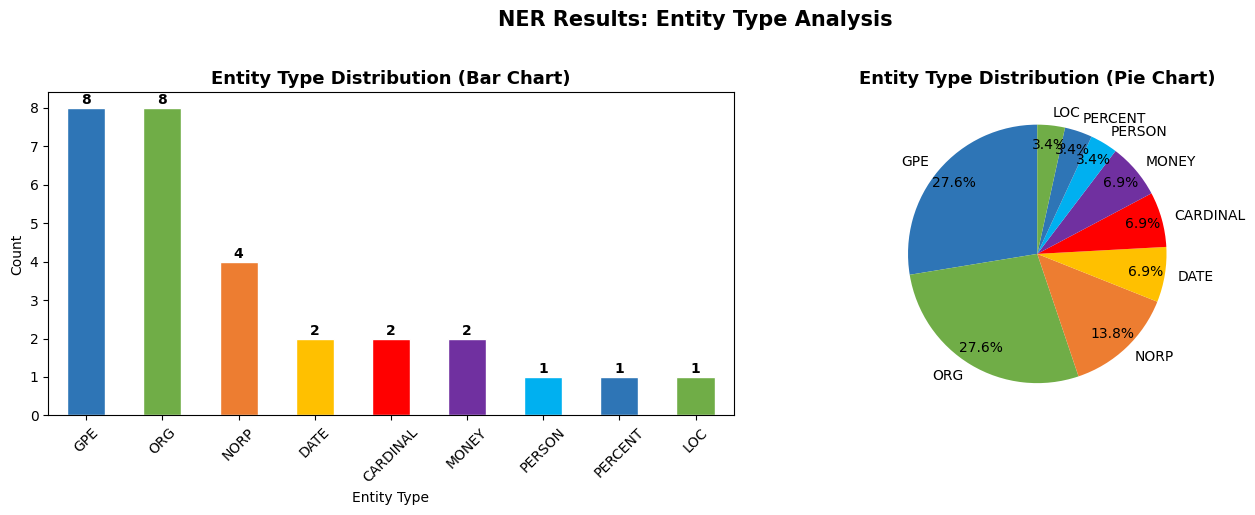

✅ Chart saved as 'entity_distribution.png'


In [29]:
# ─── ASSIGNMENT CELL 2: Entity Distribution Visualisation ────────────────────
# Visualise which entity types appear most across your articles

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# TODO: Replace 'df_combined' with your actual combined DataFrame
# Example using the news article from Section 5:
df_viz_sample = pd.DataFrame(
    [(ent.text.strip(), ent.label_) for ent in nlp(news_article).ents],
    columns=['text', 'type']
)

type_counts = df_viz_sample['type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors_bar = ['#2E75B6', '#70AD47', '#ED7D31', '#FFC000', '#FF0000', '#7030A0', '#00B0F0']
type_counts.plot(kind='bar', ax=axes[0], color=colors_bar[:len(type_counts)], edgecolor='white')
axes[0].set_title('Entity Type Distribution (Bar Chart)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Entity Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 0.1, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(type_counts.values, labels=type_counts.index,
            colors=colors_bar[:len(type_counts)], autopct='%1.1f%%',
            startangle=90, pctdistance=0.85)
axes[1].set_title('Entity Type Distribution (Pie Chart)', fontsize=13, fontweight='bold')

plt.suptitle('NER Results: Entity Type Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('entity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as 'entity_distribution.png'")

In [30]:
# ─── ASSIGNMENT CELL 3: Error Analysis ───────────────────────────────────────
# Manually annotate 1-2 short paragraphs and compare against model predictions

# Example: manually annotated gold standard for one article paragraph
my_paragraph = """
REPLACE THIS WITH A PARAGRAPH FROM ONE OF YOUR ARTICLES.
For example: Narendra Modi met Angela Merkel in Berlin on June 15, 2023.
The two leaders discussed trade relations worth $20 billion.
"""

# Your manual gold annotation (add entities YOU identified when reading the paragraph)
my_gold_entities = [
    # Format: ("entity text exactly as in paragraph", "ENTITY_TYPE")
    ("Narendra Modi", "PERSON"),
    ("Angela Merkel", "PERSON"),
    ("Berlin", "GPE"),
    ("June 15, 2023", "DATE"),
    ("$20 billion", "MONEY"),
]

# Run model and compare
doc_my = nlp(my_paragraph)
model_predictions = [(ent.text.strip(), ent.label_) for ent in doc_my.ents]

gold_set = set(my_gold_entities)
pred_set = set(model_predictions)

tp = gold_set & pred_set
fp = pred_set - gold_set
fn = gold_set - pred_set

precision = len(tp) / (len(tp) + len(fp)) if (len(tp) + len(fp)) > 0 else 0
recall    = len(tp) / (len(tp) + len(fn)) if (len(tp) + len(fn)) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print("MY ERROR ANALYSIS REPORT")
print("=" * 55)
print(f"Paragraph: '{my_paragraph.strip()[:100]}...'")
print(f"\n✅ Correctly identified: {list(tp)}")
print(f"❌ False positives:      {list(fp)}")
print(f"❌ False negatives:      {list(fn)}")
print(f"\nPrecision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"F1 Score  : {f1:.3f}")
print("\n📝 Write your error analysis below:")
print("   - What types of errors did the model make?")
print("   - Why do you think these errors occurred?")
print("   - How would you fix them (e.g., different model, post-processing rules)?")

MY ERROR ANALYSIS REPORT
Paragraph: 'REPLACE THIS WITH A PARAGRAPH FROM ONE OF YOUR ARTICLES.
For example: Narendra Modi met Angela Merke...'

✅ Correctly identified: [('Narendra Modi', 'PERSON'), ('June 15, 2023', 'DATE'), ('Angela Merkel', 'PERSON'), ('$20 billion', 'MONEY'), ('Berlin', 'GPE')]
❌ False positives:      [('two', 'CARDINAL')]
❌ False negatives:      []

Precision : 0.833
Recall    : 1.000
F1 Score  : 0.909

📝 Write your error analysis below:
   - What types of errors did the model make?
   - Why do you think these errors occurred?
   - How would you fix them (e.g., different model, post-processing rules)?


---
## 📚 Summary & Key Takeaways

### What We Covered

| Concept | Key Idea |
|---------|----------|
| **NER Definition** | Identifies and classifies named real-world entities in text |
| **Entity Types** | PERSON, ORG, GPE, DATE, MONEY, PRODUCT, EVENT, and domain-specific types |
| **IOB/BIOES** | Encoding schemes for multi-token entity spans; B=Beginning, I=Inside, O=Outside |
| **spaCy NER** | Fast, production-ready; CNN-based transition system; 90+ F1 with trf model |
| **NLTK NER** | Rule/statistical based; good for teaching; lower accuracy than neural models |
| **BERT NER** | State-of-the-art (~93% F1 on CoNLL-2003); requires fine-tuning; higher compute |
| **Span-Level F1** | Standard NER metric; requires exact boundary AND type match; no partial credit |
| **Error Types** | Boundary errors, type confusion, false negatives, false positives |

### The Golden Rule of NER
> **Always spot-check your model's output.** NER is a powerful tool but not infallible. Think of it as a search engine that generates entity candidates — not as ground truth. Manual review of a random sample is essential before deploying any NER system in production.

### Library Summary

| Library | Best For | Install Command |
|---------|----------|-----------------|
| `spacy` | Production NER, speed | `pip install spacy && python -m spacy download en_core_web_sm` |
| `nltk` | Teaching, rule-based | `pip install nltk` |
| `transformers` | SOTA accuracy, fine-tuning | `pip install transformers` |
| `seqeval` | NER evaluation (CoNLL F1) | `pip install seqeval` |

---

### 📖 References
1. Peter Song (2025). *Using Transformers for Named Entity Recognition*. ML Journey. https://mljourney.com
2. GeeksforGeeks (2026). *Named Entity Recognition*. https://www.geeksforgeeks.org/named-entity-recognition/
3. Jonathan Stray / littlecolumns (2019). *Named Entity Recognition Notebook*. https://colab.research.google.com/github/littlecolumns/ds4j-notebooks
4. Lample et al. (2016). *Neural Architectures for Named Entity Recognition*. NAACL.
5. Devlin et al. (2018). *BERT: Pre-training of Deep Bidirectional Transformers*. NAACL.
6. spaCy Documentation. https://spacy.io/usage/linguistic-features#named-entities
7. HuggingFace Transformers Documentation. https://huggingface.co/docs/transformers/tasks/token_classification

---
*Gudsky Research Foundation · Research Intake 2026 · Day 15 · Natural Language Processing*